In [1]:
import numpy as np
from pathlib import Path
import matplotlib as mpl
from matplotlib import pyplot as plt

import xarray as xr
import warnings
import pandas as pd
import geopandas as gpd

import cartopy.crs as ccrs
from cartopy.crs import Geodetic, Stereographic, PlateCarree
import cartopy
from shapely.geometry import Polygon

warnings.simplefilter("ignore")

In [2]:
# Plot relevant parameters
suptitle_size = 20
title_size = 16
mapsize = (16, 8)
extent = (2.5, 27.5, 52, 62)
lon_mid = np.mean(extent[:2])
lat_mid = np.mean(extent[2:])
map_projection = Stereographic(central_longitude=lon_mid, central_latitude=lat_mid,)
def basemap(ax):
    ax.set_extent(extent, PlateCarree())
    ax.add_feature(cartopy.feature.LAND)
    ax.add_feature(cartopy.feature.COASTLINE)
    ax.gridlines(draw_labels=["left", "bottom"], y_inline=False,)
    return ax

In [3]:
def make_sample_point(
        location_name, location_id, location_id_old, sample_kind, genomic_data, order, sea, location_lat, location_lon
        ):
        return dict(
                location_name=location_name, 
                location_id=location_id,
                location_id_old=location_id_old,
                sample_kind=sample_kind,
                genomic_data=genomic_data,
                order=order,
                sea=sea,
                geometry=gpd.points_from_xy([location_lon], [location_lat], crs=ccrs.Geodetic())[0],
        )

In [4]:
sample_test = [
        make_sample_point('KB03', 'KB03', 'KB03', 'real', True, 11, 'baltic', 54.692, 10.1035),
        make_sample_point('SW08', 'SW08', 'SW08', 'real', True, 13, 'baltic', 54.413, 11.617),
        make_sample_point('Boknis_Eck', 'BOK', 'BE01', 'real', True, 12, 'baltic', 54.5169, 10.034),
        make_sample_point('Gdynia', 'GDY', 'GD01', 'real', True, 19, 'baltic', 54.5829, 18.6042),
        make_sample_point('IU7_c', 'IU7', 'IU07', 'real', False, 28, 'baltic', 59.489, 21.2021),
        make_sample_point('LL17_c', 'LL17', 'LL17', 'real', False, 27, 'baltic', 59.02, 21.0478),
        make_sample_point('Finland', 'FIN', 'FI01', 'real', True, 29, 'baltic', 59.77, 23.2663),
        make_sample_point('Speicherkoog_moved', 'SK02', 'SK02', 'moved', True, 1, 'northsea', 54.11, 8.5),
        make_sample_point('Wilhelmshaven_moved', 'WH02', 'WH02', 'moved', True, 0, 'northsea', 53.637, 8.15),
        make_sample_point('Kategat01', 'KG01', 'KG01', 'digital', False, 10, 'northsea', 56.35, 11.8),
        make_sample_point('Kategat02', 'KG02', 'KG02', 'digital', False, 9, 'northsea', 57.0, 11.5),
        make_sample_point('Skagerak01', 'SR01', 'SR01', 'digital', False, 7, 'northsea', 58.0, 10.5),
        make_sample_point('Skagerak02', 'SR02', 'SR02', 'digital', False, 5, 'northsea', 57.5, 8.0),
        make_sample_point('JB01', 'JB01', 'JB01', 'digital', False, 4, 'northsea', 56.5, 7.2),
        make_sample_point('DeutscheBucht01', 'DB01', 'DB01', 'digital', False, 3, 'northsea', 55.5, 7.0),
        make_sample_point('DeutscheBucht02', 'DB02', 'DB02', 'digital', False, 2, 'northsea', 54.5, 7.4),
        make_sample_point('BalticPropper01', 'BP01', 'BP01', 'digital', False, 17, 'baltic', 55.5, 17.2),
        make_sample_point('BalticPropper02', 'BP02', 'BP02', 'digital', False, 18, 'baltic', 56.1, 18.5),
        make_sample_point('EG01', 'EG01', 'EG01', 'digital', False, 24, 'baltic', 57.4, 20.2),
        make_sample_point('EG02', 'EG02', 'EG02', 'digital', False, 25, 'baltic', 58.3, 20.6),
        make_sample_point('Skagerak03', 'SR03', 'SR03', 'digital', False, 6, 'northsea', 58.3, 9.3),
        make_sample_point('WG01', 'WG01', 'WG01', 'digital', False, 21, 'baltic', 57.0, 17.4),
        make_sample_point('WG02', 'WG02', 'WG02', 'digital', False, 22, 'baltic', 58.5, 18.5),
        make_sample_point('BalticPropper03', 'BP03', 'BP03', 'digital', False, 20, 'baltic', 55.4, 19.3),
        make_sample_point('BB23', 'BB23', 'BB23', 'real', False, 15, 'baltic', 55.2912, 15.7503),
        make_sample_point('BB36', 'BB36', 'BB36', 'real', True, 16, 'baltic', 54.9589, 15.9981),
        make_sample_point('GB96', 'GB96', 'GB96', 'real', True, 23, 'baltic', 56.9165, 19.5827),
        make_sample_point('H21', 'H21', 'HR21', 'real', True, 14, 'baltic', 54.9433, 13.4914),
        make_sample_point('Speicherkoog', 'SK', 'SK', 'real', True, 1, 'northsea', 54.0929, 8.9487),
        make_sample_point('Wilhelmshaven', 'WH', 'WH', 'real', True, 0, 'northsea', 53.513, 8.149),
]

In [5]:
# Source - https://stackoverflow.com/a/5946359
# Posted by blubb, modified by community. See post 'Timeline' for change history
# Retrieved 2026-06-23, License - CC BY-SA 4.0

ds = sample_test
sample_points = {}
for column in sample_test[0].keys():
  sample_points[column] = list(location[column] for location in sample_test)
gdf_sample_points = gpd.GeoDataFrame(sample_points, crs=ccrs.Geodetic()).sort_values("order")
gdf_sample_points

,location_name,location_id,location_id_old,sample_kind,genomic_data,order,sea,geometry
8,Wilhelmshaven_moved,WH02,WH02,moved,True,0,northsea,POINT (8.15 53.637)
29,Wilhelmshaven,WH,WH,real,True,0,northsea,POINT (8.149 53.513)
28,Speicherkoog,SK,SK,real,True,1,northsea,POINT (8.9487 54.0929)
7,Speicherkoog_moved,SK02,SK02,moved,True,1,northsea,POINT (8.5 54.11)
15,DeutscheBucht02,DB02,DB02,digital,False,2,northsea,POINT (7.4 54.5)
14,DeutscheBucht01,DB01,DB01,digital,False,3,northsea,POINT (7 55.5)
13,JB01,JB01,JB01,digital,False,4,northsea,POINT (7.2 56.5)
12,Skagerak02,SR02,SR02,digital,False,5,northsea,POINT (8 57.5)
20,Skagerak03,SR03,SR03,digital,False,6,northsea,POINT (9.3 58.3)
11,Skagerak01,SR01,SR01,digital,False,7,northsea,POINT (10.5 58)


In [6]:
# define Paths
output_path = Path("/gxfs_work/geomar/smomw597/2025_copepods/output/SamplePoints")
output_sample_points = Path(output_path,"sample_points.shp")
output_voronoi_polygons = Path(output_path,"voronoi_polygons.shp")
output_voronoi_ocean_polygons = Path(output_path,"voronoi_ocean_polygons.shp")

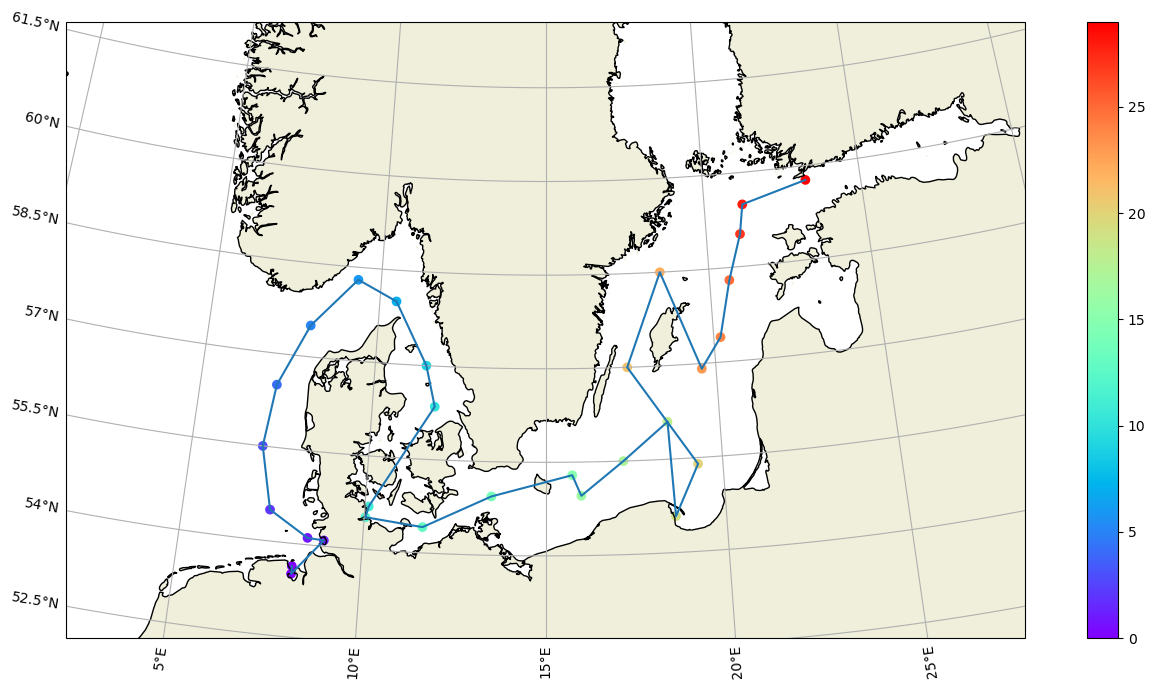

In [7]:
gdf_sample_points_map = gdf_sample_points.to_crs(map_projection)
fig = plt.figure(figsize=mapsize)
ax_map = fig.add_subplot(projection=map_projection)
basemap(ax_map)
gdf_sample_points_map.plot(ax=ax_map, column="order", cmap='rainbow', legend=True)
ax_map.plot(gdf_sample_points_map.geometry.x, gdf_sample_points_map.geometry.y)
plt.show()

In [9]:
# Define the the radius of interest around the sample points
centroid = gdf_sample_points.dissolve().centroid.to_crs(Geodetic())
area_of_interest = (
    gpd.GeoDataFrame(
        gdf_sample_points.location_id,
        geometry=gdf_sample_points.to_crs(
            ccrs.Orthographic(
                # Set the central position of the Projection to the centroid
                central_longitude=centroid.x.values[0], 
                central_latitude=centroid.y.values[0]
                )
            )
        # Set the Bufferdistance to 125 000 metres
        .buffer(distance=1.25e5)
        # Reproject to the map projection
        .to_crs(map_projection)
        )
        # Dissolve the polygons to one single Polygon
        .dissolve()
    )

In [10]:
# Build geodataframe for voronoi polygons
gdf_voronoi = gdf_sample_points.voronoi_polygons()
sample_polygons = { 
    'geometry': gdf_voronoi,
    }
gdf_voronoi = gpd.GeoDataFrame(sample_polygons).to_crs(map_projection)

In [17]:
# Reorder the polygons so that the IDs are correct
gdf_voronoi_polygons = gpd.sjoin(left_df=gdf_voronoi, right_df=gdf_sample_points, how="left", rsuffix="polygon")
gdf_voronoi_polygons.rename(columns={'index_polygon':'index', 'location_id': 'polygon_id'}, inplace = True)
gdf_voronoi_polygons = gdf_voronoi_polygons.set_index('index').sort_index()

In [18]:
gdf_voronoi_clipped = gdf_voronoi_polygons.clip(area_of_interest).sort_index()

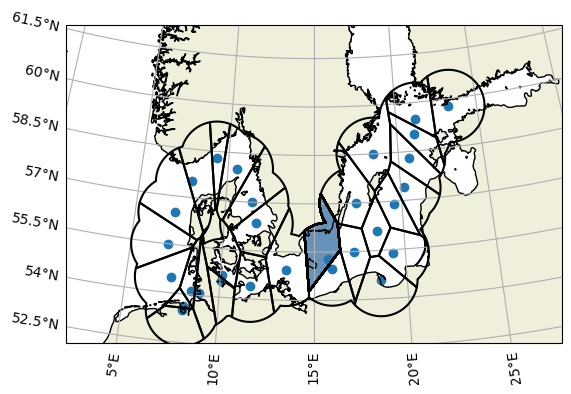

In [21]:
fig = plt.figure()
ax_map = fig.add_subplot(projection=map_projection)
basemap(ax_map)
gdf_voronoi_clipped.plot(ax=ax_map, alpha=0.5, column="polygon_id",)
gdf_voronoi_clipped.boundary.plot(ax=ax_map, color="k",)
gdf_sample_points_map.plot(ax=ax_map)
map_extent = ax_map.get_extent(crs=map_projection)
plt.show()

In [ ]:
gdf_voronoi_clipped.to_file(output_voronoi_polygons)

In [25]:
ocean_50m = cartopy.feature.NaturalEarthFeature('physical', 'ocean', '50m')

for i, poly in enumerate(ocean_50m.intersecting_geometries(map_extent)):
    if i == 0:
        polygon = list([poly])
    else:
        polygon.append(poly)
ocean_poly = gpd.GeoDataFrame({'geometry':polygon}, crs=Geodetic()).to_crs(map_projection).clip(area_of_interest)
ocean_poly
gdf_voronoi_ocean = gdf_voronoi_clipped.clip(ocean_poly).sort_index()
# devide by 10^6 because the unit we need is km^2 while th output unit is m^2
gdf_voronoi_ocean['area'] = gdf_voronoi_ocean.clip(ocean_poly).sort_index().area/1e6
gdf_voronoi_ocean

,geometry,Sample,PolygonID,SampleID_old,SampleKind,GenomicData,order,sea,area
index,,,,,,,,,
0,"MULTIPOLYGON (((-405759.252 -184049.375, -4029...",KB03,KB03,KB03,real,True,11,baltic,7131.761408
1,"POLYGON ((-254071.962 -228942.318, -255090.543...",SW08,SW08,SW08,real,True,13,baltic,9176.559548
2,"POLYGON ((-269963.882 -270316.108, -273132.878...",Boknis_Eck,BOK,BE01,real,True,12,baltic,930.554160
3,"POLYGON ((204618.036 -196163.794, 316799.647 -...",Gdynia,GDY,GD01,real,True,19,baltic,6573.512733
4,"POLYGON ((242882.202 275118.952, 225673.069 29...",IU7_c,IU7,IU07,real,False,28,baltic,21011.796150
5,"POLYGON ((428608.732 260926.853, 433648.978 25...",LL17_c,LL17,LL17,real,False,27,baltic,12120.685177
6,"POLYGON ((376387.286 395614.452, 382180.529 39...",Finland,FIN,FI01,real,True,29,baltic,18398.696027
7,"POLYGON ((-479346.261 -304535.461, -414663.882...",Speicherkoog_moved,SK,SK02,moved,True,1,northsea,5747.241367
8,"POLYGON ((-424311.271 -335177.235, -426399.783...",Wilhelmshaven_moved,WH,WH02,moved,True,0,northsea,5212.630008


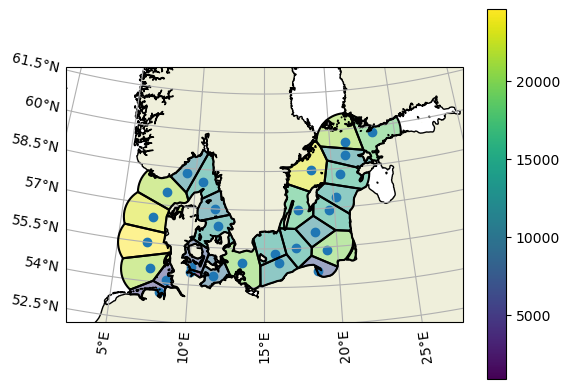

In [26]:
fig = plt.figure()
ax_map = fig.add_subplot(projection=map_projection)
basemap(ax_map)
gdf_voronoi_ocean.plot(ax=ax_map, alpha=0.5, column="area", legend=True)
gdf_voronoi_ocean.boundary.plot(ax=ax_map, color="k",)
gdf_sample_points.plot(ax=ax_map)
plt.show()

In [ ]:
gdf_voronoi_ocean.to_file(output_voronoi_ocean_polygons)

In [ ]:
gdf_sample_points.to_file(output_sample_points)